/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_59602/169664309.py:50: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  k_sol = fsolve(dispersion_equation, k_guess, args=(omega, h, D))[0]
/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_59602/169664309.py:50: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  k_sol = fsolve(dispersion_equation, k_guess, args=(omega, h, D))[0]


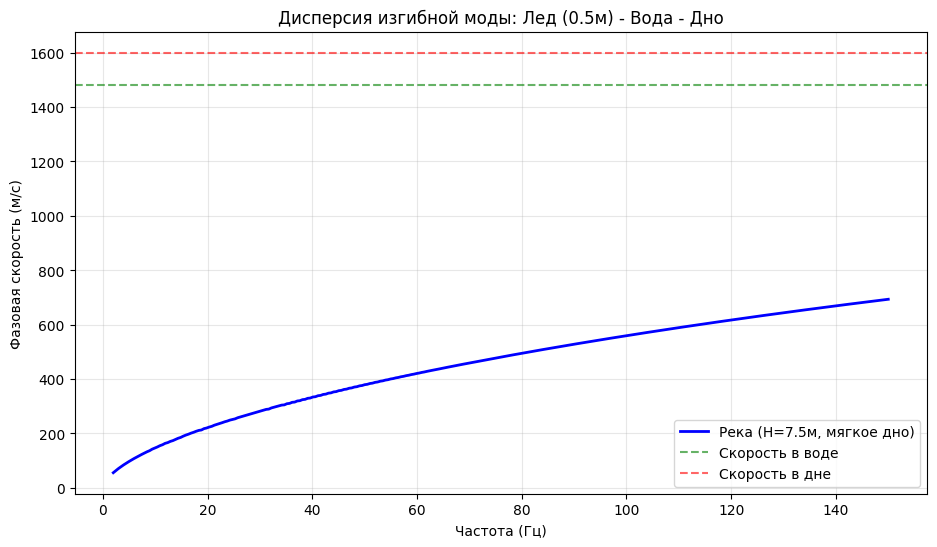

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# --- Параметры среды ---
# Лед (Ice)
E = 6e9          # Па
nu = 0.3
rho_i = 917      # кг/м3
h_ice = 0.5      # м (фиксированная для сравнения эффектов дна)

# Вода (River water)
rho_w = 1000     # кг/м3 (пресная речная вода)
c_w = 1480       # м/с
H_water = 7.5     # м (речные условия обычно мелководные)

# Дно (Bottom half-space - "Мягкий ил/песок")
rho_b = 1800     # кг/м3
c_b = 1600       # м/с (продольная волна в грунте)

def dispersion_equation(k, omega, h, D):
    # Вертикальные волновые числа
    # Используем комплексные числа, чтобы избежать ошибок при k < omega/c
    gamma_w = np.sqrt(k**2 - (omega/c_w)**2 + 0j)
    gamma_b = np.sqrt(k**2 - (omega/c_b)**2 + 0j)
    
    # Коэффициент отражения от дна (плоская волна)
    V = (rho_b * gamma_w - rho_w * gamma_b) / (rho_b * gamma_w + rho_w * gamma_b)
    
    # Модификатор импеданса слоя воды конечной глубины
    # exp(-2*gamma*H) описывает проход волны туда-обратно
    layer_term = (1 + V * np.exp(-2 * gamma_w * H_water)) / \
                 (1 - V * np.exp(-2 * gamma_w * H_water))
    
    # Давление нагрузки
    p_loading = (rho_w * omega**2 / gamma_w) * layer_term
    
    # Итоговое уравнение пластины Кирхгофа
    return np.real(D * k**4 - rho_i * h * omega**2 + p_loading)

def solve_for_frequencies(freqs, h):
    D = (E * h**3) / (12 * (1 - nu**2))
    v_phase = []
    
    k_guess = 0.1 # Начальное приближение
    
    for f in freqs:
        omega = 2 * np.pi * f
        # Численное решение
        k_sol = fsolve(dispersion_equation, k_guess, args=(omega, h, D))[0]
        v_phase.append(omega / k_sol)
        k_guess = k_sol # Используем предыдущий корень для стабильности
        
    return np.array(v_phase)

# --- Генерация данных ---
f_axis = np.linspace(2, 150, 300)
v_flexural_layered = solve_for_frequencies(f_axis, h_ice)

# Для сравнения: случай "бесконечной" глубины (без влияния дна)
H_water_infinite = 1000
def loading_infinite(k, omega):
    gamma_w = np.sqrt(k**2 - (omega/c_w)**2 + 0j)
    return (rho_w * omega**2 / gamma_w)

# --- Визуализация ---
plt.figure(figsize=(11, 6))
plt.plot(f_axis, v_flexural_layered, 'b-', linewidth=2, label=f'Река (H={H_water}м, мягкое дно)')
plt.axhline(y=c_w, color='g', linestyle='--', alpha=0.6, label='Скорость в воде')
plt.axhline(y=c_b, color='r', linestyle='--', alpha=0.6, label='Скорость в дне')

plt.title(f'Дисперсия изгибной моды: Лед ({h_ice}м) - Вода - Дно', fontsize=12)
plt.xlabel('Частота (Гц)')
plt.ylabel('Фазовая скорость (м/с)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

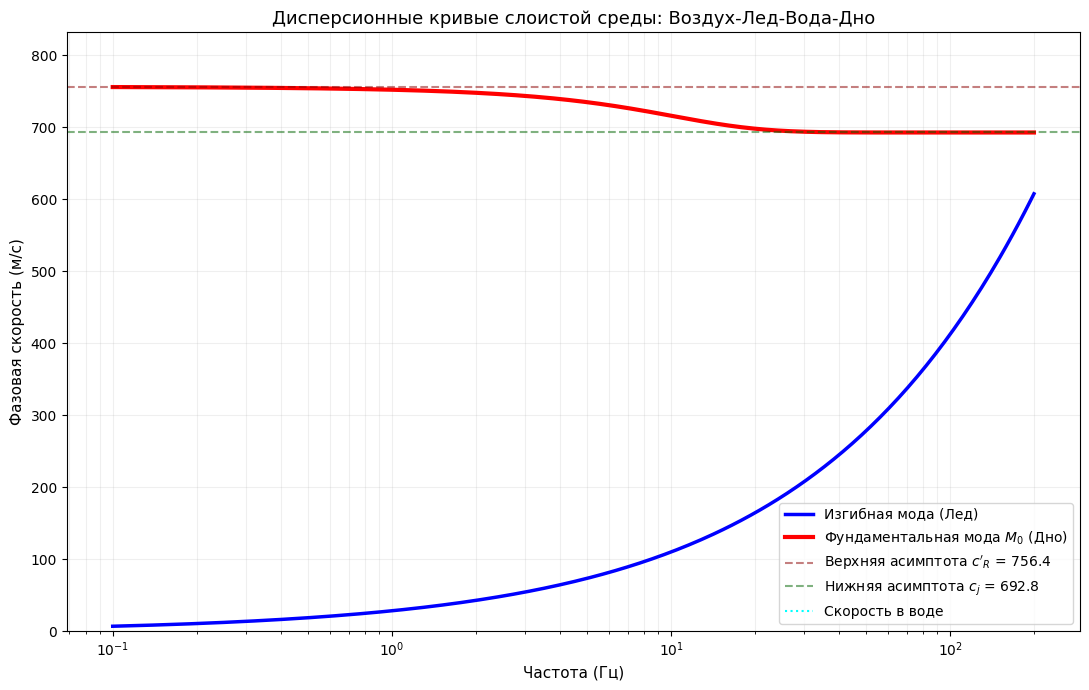

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# --- Параметры системы (все в СИ) ---
params = {
    'ice': {
        'h': 0.5, 'rho': 917, 'E': 7e9, 'nu': 0.33
    },
    'water': {
        'h': 10.0, 'rho': 1000, 'c': 1480
    },
    'bottom': {
        'rho': 1800, 'cp': 2200, 'cs': 800
    }
}

def get_accurate_asymptotes(p):
    """Определение теоретических пределов для фундаментальной моды"""
    cp, cs = p['bottom']['cp'], p['bottom']['cs']
    cw, rw, rb = p['water']['c'], p['water']['rho'], p['bottom']['rho']
    
    # Верхняя (НЧ) - чистый Рэлей дна
    def r_eq(c):
        k = 1.0 / c
        gp = np.sqrt(k**2 - (1.0/cp)**2 + 0j)
        gs = np.sqrt(k**2 - (1.0/cs)**2 + 0j)
        return np.real((2*k**2 - (1.0/cs)**2)**2 - 4 * k**2 * gp * gs)
    c_up = fsolve(r_eq, cs * 0.91)[0]
    
    # Нижняя (ВЧ) - Шолте (вода-дно)
    def s_eq(c):
        k = 1.0 / c
        gp, gs, gw = [np.sqrt(k**2 - (1.0/v)**2 + 0j) for v in [cp, cs, cw]]
        R = (2*k**2 - (1.0/cs)**2)**2 - 4 * k**2 * gp * gs
        L = (rw/rb) * ((1.0/cs)**4 * gp / gw)
        return np.real(R + L)
    c_low = fsolve(s_eq, c_up * 0.85)[0]
    
    return c_up, c_low

def solve_system(f_range, p):
    """Расчет обеих мод"""
    # Параметры льда
    D = (p['ice']['E'] * p['ice']['h']**3) / (12 * (1 - p['ice']['nu']**2))
    m_i = p['ice']['rho'] * p['ice']['h']
    # Параметры воды/дна
    cp, cs, rb = p['bottom']['cp'], p['bottom']['cs'], p['bottom']['rho']
    cw, rw, H = p['water']['c'], p['water']['rho'], p['water']['h']
    
    v_flex = []
    v_m0 = []
    
    # Стартовые приближения
    c_up, _ = get_accurate_asymptotes(p)
    guess_m0 = c_up
    
    for f in f_range:
        omega = 2 * np.pi * f
        
        # 1. Изгибная мода льда (возрастает)
        def eq_ice(k):
            if k <= 0: return 1e10
            return D*k**4 - m_i*omega**2 - (rw*omega**2)/(k*np.tanh(k*H))
        k_ice = fsolve(eq_ice, (m_i*omega**2/D)**0.25)[0]
        v_flex.append(omega / k_ice)
        
        # 2. Фундаментальная мода M0 (убывает)
        def eq_m0(c):
            k = omega / c
            gp, gs, gw = [np.sqrt(k**2 - (omega/v)**2 + 0j) for v in [cp, cs, cw]]
            R = (2*k**2 - (omega/cs)**2)**2 - 4 * k**2 * gp * gs
            L = (rw/rb) * ((omega/cs)**4 * gp / gw) * np.tanh(gw * H)
            return np.real(R + L)
        
        c_m0 = fsolve(eq_m0, guess_m0)[0]
        v_m0.append(c_m0)
        guess_m0 = c_m0 # динамическое приближение
        
    return np.array(v_flex), np.array(v_m0)

# --- Расчет ---
freqs = np.logspace(-1, 2.3, 300)
v_flex, v_m0 = solve_system(freqs, params)
c_up, c_low = get_accurate_asymptotes(params)

# --- Визуализация ---
plt.figure(figsize=(11, 7))

# Кривые
plt.semilogx(freqs, v_flex, 'b-', lw=2.5, label='Изгибная мода (Лед)')
plt.semilogx(freqs, v_m0, 'r-', lw=3, label='Фундаментальная мода $M_0$ (Дно)')

# Асимптоты
plt.axhline(y=c_up, color='darkred', ls='--', alpha=0.5, label=f"Верхняя асимптота $c'_R$ = {c_up:.1f}")
plt.axhline(y=c_low, color='darkgreen', ls='--', alpha=0.5, label=f"Нижняя асимптота $c_j$ = {c_low:.1f}")
plt.axhline(y=params['water']['c'], color='cyan', ls=':', label='Скорость в воде')

plt.title('Дисперсионные кривые слоистой среды: Воздух-Лед-Вода-Дно', fontsize=13)
plt.xlabel('Частота (Гц)', fontsize=11)
plt.ylabel('Фазовая скорость (м/с)', fontsize=11)
plt.grid(True, which="both", alpha=0.2)
plt.legend(loc='best', frameon=True)
plt.ylim(0, max(v_flex.max(), c_up) * 1.1)

plt.tight_layout()
plt.show()

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_7664/1136784606.py:90: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  c_h1 = fsolve(eq_hydro, cw + 50)[0]
/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_7664/1136784606.py:93: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  c_h2 = fsolve(eq_hydro, cw + 400)[0]
/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_7664/1136784606.py:90: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  c_h1 = fsolve(eq_hydro, cw + 50)[0]


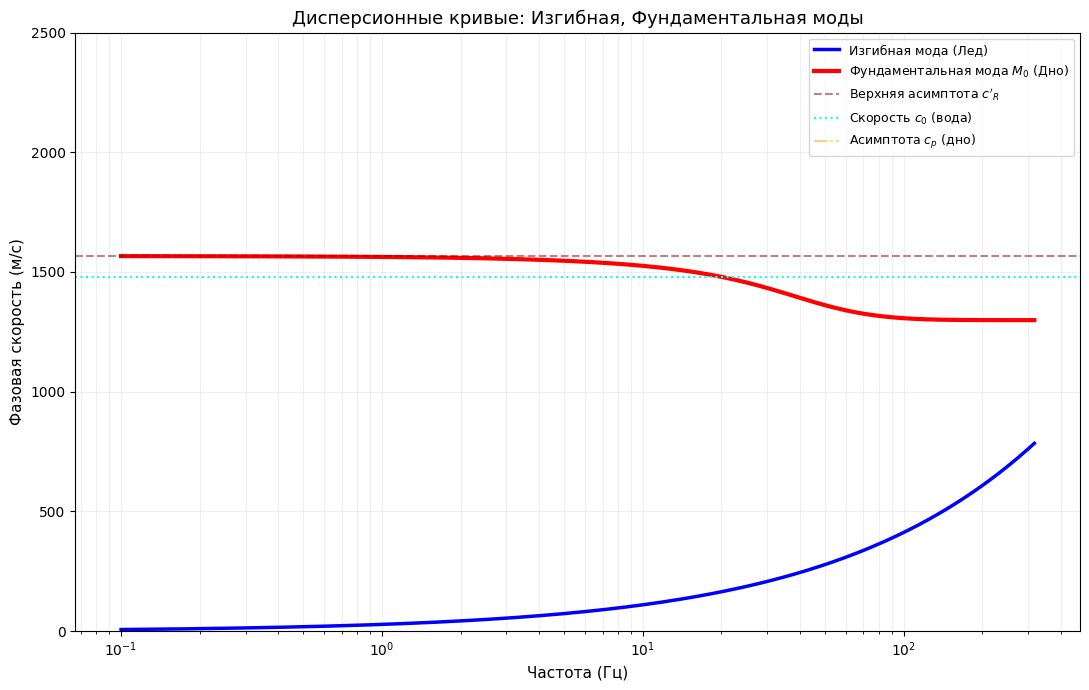

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# --- Параметры системы (все в СИ) ---
params = {
    'ice': {
        'h': 0.5, 'rho': 917, 'E': 7e9, 'nu': 0.33
    },
    'water': {
        'h': 8.0, 'rho': 1000, 'c': 1480
    },
    'bottom': {
        'rho': 2000, 'cp': 3000, 'cs': 1700
    }
}

def get_accurate_asymptotes(p):
    cp, cs = p['bottom']['cp'], p['bottom']['cs']
    cw, rw, rb = p['water']['c'], p['water']['rho'], p['bottom']['rho']
    
    def r_eq(c):
        k = 1.0 / c
        gp = np.sqrt(k**2 - (1.0/cp)**2 + 0j)
        gs = np.sqrt(k**2 - (1.0/cs)**2 + 0j)
        return np.real((2*k**2 - (1.0/cs)**2)**2 - 4 * k**2 * gp * gs)
    c_up = fsolve(r_eq, cs * 0.91)[0]
    
    def s_eq(c):
        k = 1.0 / c
        gp, gs, gw = [np.sqrt(k**2 - (1.0/v)**2 + 0j) for v in [cp, cs, cw]]
        R = (2*k**2 - (1.0/cs)**2)**2 - 4 * k**2 * gp * gs
        L = (rw/rb) * ((1.0/cs)**4 * gp / gw)
        return np.real(R + L)
    c_low = fsolve(s_eq, c_up * 0.85)[0]
    
    return c_up, c_low

def solve_system(f_range, p):
    D = (p['ice']['E'] * p['ice']['h']**3) / (12 * (1 - p['ice']['nu']**2))
    m_i = p['ice']['rho'] * p['ice']['h']
    cp, cs, rb = p['bottom']['cp'], p['bottom']['cs'], p['bottom']['rho']
    cw, rw, H = p['water']['c'], p['water']['rho'], p['water']['h']
    
    v_flex, v_m0 = [], []
    v_hydro = [[] for _ in range(2)] # Считаем первые две гидроакустические моды
    
    c_up, _ = get_accurate_asymptotes(p)
    guess_m0 = c_up
    
    for f in f_range:
        omega = 2 * np.pi * f
        
        # 1. Изгибная мода льда (как была)
        def eq_ice(k):
            if k <= 0: return 1e10
            return D*k**4 - m_i*omega**2 - (rw*omega**2)/(k*np.tanh(k*H))
        k_ice = fsolve(eq_ice, (m_i*omega**2 / D)**0.25)[0]
        v_flex.append(omega / k_ice)
        
        # 2. Фундаментальная мода M0 (как была)
        def eq_m0(c):
            k = omega / c
            gp, gs, gw = [np.sqrt(k**2 - (omega/v)**2 + 0j) for v in [cp, cs, cw]]
            R = (2*k**2 - (omega/cs)**2)**2 - 4 * k**2 * gp * gs
            L = (rw/rb) * ((omega/cs)**4 * gp / gw) * np.tanh(gw * H)
            return np.real(R + L)
        
        c_m0 = fsolve(eq_m0, guess_m0)[0]
        v_m0.append(c_m0)
        guess_m0 = c_m0 

        # 3. Гидроакустические моды (Дополнение)
        # Ищем корни в интервале между cw и cp
        def eq_hydro(c):
            k = omega / c
            # В воде kz действительный для волноводных мод
            kz_w = np.sqrt((omega/cw)**2 - k**2 + 0j)
            # Импеданс дна (упрощенно для жидкого эквивалента или полного упругого)
            gp, gs = [np.sqrt(k**2 - (omega/v)**2 + 0j) for v in [cp, cs]]
            R = (2*k**2 - (omega/cs)**2)**2 - 4 * k**2 * gp * gs
            # Условие интерференции: tan(kz_w * H + фазовые сдвиги) = 0
            # Здесь используем полное дисперсионное уравнение для волновода
            ice_term = D*k**4 - m_i*omega**2
            bottom_term = (rw * omega**4 * gp) / (rb * cs**4 * R)
            return np.real(np.tan(kz_w * H) - (rw * omega**2) / (kz_w * ice_term) + bottom_term/kz_w)

        # Поиск мод (сканируем диапазон скоростей)
        # Мода 1
        c_h1 = fsolve(eq_hydro, cw + 50)[0]
        v_hydro[0].append(c_h1 if c_h1 > cw and c_h1 < cp else np.nan)
        # Мода 2
        c_h2 = fsolve(eq_hydro, cw + 400)[0]
        v_hydro[1].append(c_h2 if c_h2 > cw and c_h2 < cp else np.nan)
        
    return np.array(v_flex), np.array(v_m0), v_hydro

# --- Расчет ---
freqs = np.logspace(-1, 2.5, 300)
v_flex, v_m0, v_hydros = solve_system(freqs, params)
c_up, c_low = get_accurate_asymptotes(params)

# --- Визуализация ---
plt.figure(figsize=(11, 7))

plt.semilogx(freqs, v_flex, 'b-', lw=2.5, label='Изгибная мода (Лед)')
plt.semilogx(freqs, v_m0, 'r-', lw=3, label='Фундаментальная мода $M_0$ (Дно)')

# Гидроакустические моды
# plt.semilogx(freqs, v_hydros[0], 'g--', lw=1.5, label='Гидроакустическая мода 1')
# plt.semilogx(freqs, v_hydros[1], 'm--', lw=1.5, label='Гидроакустическая мода 2')

plt.axhline(y=c_up, color='darkred', ls='--', alpha=0.5, label=f"Верхняя асимптота $c'_R$")
plt.axhline(y=params['water']['c'], color='cyan', ls=':', label='Скорость $c_0$ (вода)')
plt.axhline(y=params['bottom']['cp'], color='orange', ls='-.', alpha=0.5, label='Асимптота $c_p$ (дно)')

plt.title('Дисперсионные кривые: Изгибная, Фундаментальная моды', fontsize=13)
plt.xlabel('Частота (Гц)', fontsize=11)
plt.ylabel('Фазовая скорость (м/с)', fontsize=11)
plt.grid(True, which="both", alpha=0.2)
plt.legend(loc='upper right', frameon=True, fontsize=9)
plt.ylim(0, 2500)

plt.tight_layout()
plt.show()

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_1826/2069679220.py:82: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  res_h = fsolve(eq_hydro, g_hydro)[0]
/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_1826/2069679220.py:82: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  res_h = fsolve(eq_hydro, g_hydro)[0]


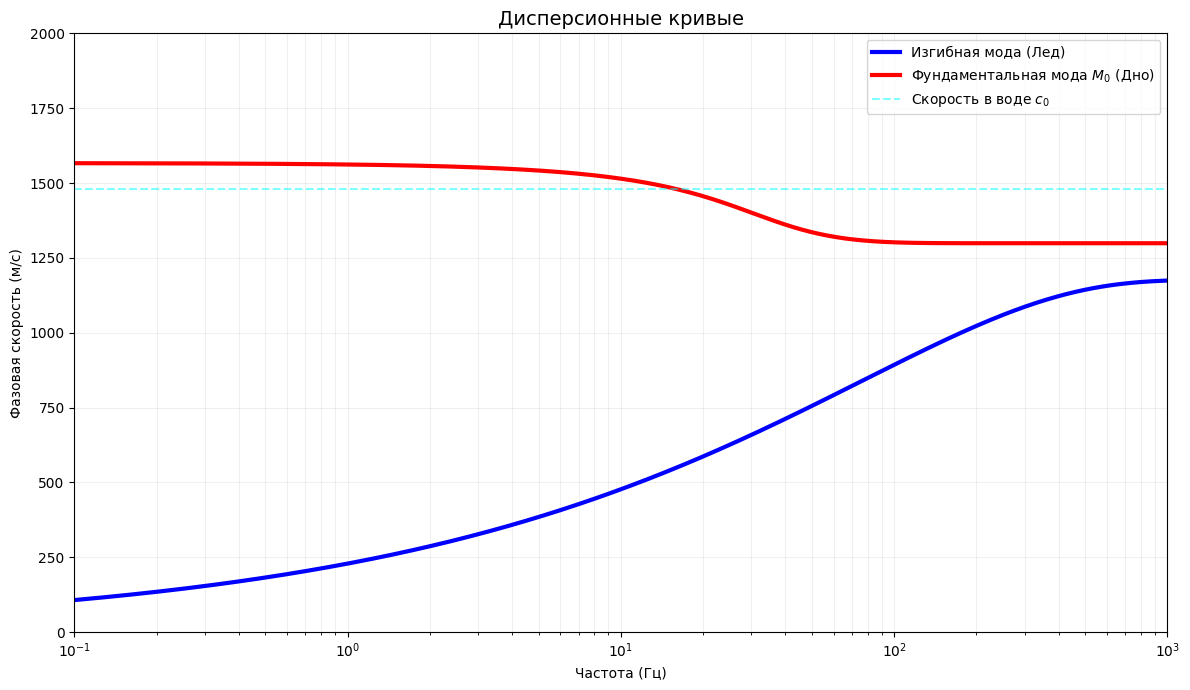

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# --- Параметры системы (все в СИ) ---
params = {
    'ice': {'h': 0.5, 'rho': 917, 'E': 7e9, 'nu': 0.33},
    'water': {'h': 10.0, 'rho': 1000, 'c': 1480},
    'bottom': {'rho': 2000, 'cp': 3000, 'cs': 1700}
}

def get_scholte_speed(rho_s, cp_s, cs_s, rho_l, c_l):
    def scholte_eq(c):
        k = 1.0 / c
        gp = np.sqrt(k**2 - (1.0/cp_s)**2 + 0j)
        gs = np.sqrt(k**2 - (1.0/cs_s)**2 + 0j)
        gw = np.sqrt(k**2 - (1.0/c_l)**2 + 0j)
        R = (2*k**2 - (1.0/cs_s)**2)**2 - 4 * k**2 * gp * gs
        L = (rho_l / rho_s) * ((1.0/cs_s)**4 * gp / gw)
        return np.real(R + L)
    return fsolve(scholte_eq, min(c_l, cs_s) * 0.9)[0]

def solve_stable(f_range, p):
    hi, rhoi, Ei, nui = p['ice']['h'], p['ice']['rho'], p['ice']['E'], p['ice']['nu']
    cw, rw, H = p['water']['c'], p['water']['rho'], p['water']['h']
    rb, cpb, csb = p['bottom']['rho'], p['bottom']['cp'], p['bottom']['cs']
    
    # Константы для льда
    csi = np.sqrt(Ei / (2 * rhoi * (1 + nui)))
    cpi = np.sqrt(Ei * (1 - nui) / (rhoi * (1 + nui) * (1 - 2*nui)))
    Di = (Ei * hi**3) / (12 * (1 - nui**2))
    mi = rhoi * hi

    # Асимптоты
    c_stone_ice = get_scholte_speed(rhoi, cpi, csi, rw, cw)
    c_stone_bot = get_scholte_speed(rb, cpb, csb, rw, cw)

    # Массивы результатов
    v_flex, v_m0, v_hydro = [], [], []
    
    g_flex = 100.0
    g_m0 = csb * 0.9
    g_hydro = cw + 50.0

    for f in f_range:
        omega = 2 * np.pi * f
        
        # 1. ИЗГИБНАЯ МОДА 
        def eq_flex(c):
            k = omega / c
            gp, gs, gw = [np.sqrt(k**2 - (omega/v)**2 + 0j) for v in [cpi, csi, cw]]
            
            R_ice = (2*k**2 - (omega/csi)**2)**2 - 4 * k**2 * gp * gs
            return np.real(R_ice * np.sinh(gp*hi) + (rw/rhoi)*(omega/csi)**4 * (gp/gw) * np.cosh(gp*hi))
        
        res_flex = fsolve(eq_flex, g_flex)[0]
        if len(v_flex) > 0 and abs(res_flex - v_flex[-1]) / v_flex[-1] > 0.3:
            v_flex.append(np.nan) # Игнорируем резкий скачок
        else:
            v_flex.append(res_flex)
            g_flex = res_flex # Обновляем догадку

        # 2. ФУНДАМЕНТАЛЬНАЯ МОДА M0
        def eq_m0(c):
            k = omega / c
            gpb, gsb, gw = [np.sqrt(k**2 - (omega/v)**2 + 0j) for v in [cpb, csb, cw]]
            R_bot = (2*k**2 - (omega/csb)**2)**2 - 4 * k**2 * gpb * gsb
            L_bot = (rw/rb) * ((omega/csb)**4 * gpb / gw) * np.tanh(gw * H)
            return np.real(R_bot + L_bot)
        
        res_m0 = fsolve(eq_m0, g_m0)[0]
        v_m0.append(res_m0)
        g_m0 = res_m0

        # 3. ГИДРОАКУСТИЧЕСКАЯ МОДА
        def eq_hydro(c):
            k = omega / c
            kz_w = np.sqrt((omega/cw)**2 - k**2 + 0j)
            return np.real(np.tan(kz_w * H) - (rw * omega**2) / (kz_w * (Di*k**4 - mi*omega**2)))

        try:
            res_h = fsolve(eq_hydro, g_hydro)[0]
            if cw < res_h < cpb and (len(v_hydro) == 0 or abs(res_h - g_hydro) < 100):
                v_hydro.append(res_h)
                g_hydro = res_h
            else: v_hydro.append(np.nan)
        except: v_hydro.append(np.nan)

    return np.array(v_flex), np.array(v_m0), np.array(v_hydro), c_stone_ice, c_stone_bot

# --- Отрисовка ---
freqs = np.logspace(-1, 3, 500)
cf, cm, ch, as_ice, as_bot = solve_stable(freqs, params)

plt.figure(figsize=(12, 7))
plt.semilogx(freqs, cf, 'b-', lw=3, label='Изгибная мода (Лед)')
plt.semilogx(freqs, cm, 'r-', lw=3, label='Фундаментальная мода $M_0$ (Дно)')
#plt.semilogx(freqs, ch, 'g--', lw=1.5, label='Гидроакустическая мода')

#plt.axhline(y=as_ice, color='blue', ls=':', alpha=0.6, label=f'Асимптота Стоунли (Лед): {as_ice:.1f}')
#plt.axhline(y=as_bot, color='red', ls=':', alpha=0.6, label=f'Асимптота Стоунли (Дно): {as_bot:.1f}')
plt.axhline(y=params['water']['c'], color='cyan', ls='--', alpha=0.5, label='Скорость в воде $c_0$')

plt.title('Дисперсионные кривые', fontsize=14)
plt.xlabel('Частота (Гц)')
plt.ylabel('Фазовая скорость (м/с)')
plt.grid(True, which="both", alpha=0.2)
plt.legend(loc='upper right', frameon=True)
plt.ylim(0, 2000)
plt.xlim(0.1, 1000)
plt.tight_layout()
plt.show()